# Generative Adversarial Network (GAN) for EEG Generation

For this section, we want to generate EEG of both classes in our data (MDDS and HS). We will seperate the data into these two classes, and do the same for both:

- Find out the general format for how the EEG files should look
    - How many channels
    - Do different files have different amounts of channels
    - What kind of data does each channel have, and how is it formatted
- Create a discriminator model
- Create a generative model

Some things to look at: 

- Is there a way to make the EEG files compatible with GAN model with torch from lecture (image data)?

- There may be fine-tuning in terms of making the neurons. Is there an optimal way to down/upsample for EEG data?
    - Is there an process to test different iterations?

The following code is used from the pipeline to do some analysis on the data:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path 
import mne

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:

# The code to find the project root for the file path
def find_project_root():
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Project root (with .git) not found")


# These are the specific file paths for the project
PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "nm000114"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_features"
RESULTS_DIR = PROJECT_ROOT / "results"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DATA_DIR:", RAW_DATA_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

# Get one specific eeg file loaded
def get_eeg_file(subject_id: str, condition: str):
    return RAW_DATA_DIR / subject_id / "eeg" / f"{subject_id}_task-{condition}_eeg.edf"

PROJECT_ROOT: /mnt/c/Users/AlexC/OneDrive/Desktop/berkeley_stuff/CHEM 277B/MSSE-277b-final-project-
RAW_DATA_DIR: /mnt/c/Users/AlexC/OneDrive/Desktop/berkeley_stuff/CHEM 277B/MSSE-277b-final-project-/data/raw/nm000114
PROCESSED_DIR: /mnt/c/Users/AlexC/OneDrive/Desktop/berkeley_stuff/CHEM 277B/MSSE-277b-final-project-/data/processed_features
RESULTS_DIR: /mnt/c/Users/AlexC/OneDrive/Desktop/berkeley_stuff/CHEM 277B/MSSE-277b-final-project-/results


In [ ]:
# Get a specific file
file_path = get_eeg_file("sub-HS1", "P300")

print(type(file_path))
print(file_path.exists())

# Load the data for the first file
raw = mne.io.read_raw_edf(file_path, preload=True)

# Gets turned into raw data
data = raw.get_data()
print("Shape: ", data.shape)

# 22 channels and 154880 timestamps

<class 'pathlib.PosixPath'>
True
Extracting EDF parameters from /mnt/c/Users/AlexC/OneDrive/Desktop/berkeley_stuff/CHEM 277B/MSSE-277b-final-project-/data/raw/nm000114/sub-HS1/eeg/sub-HS1_task-P300_eeg.edf...


Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 154879  =      0.000 ...   604.996 secs...
Shape:  (22, 154880)


At this point, I want to know whether all the files have the same shape -- what their format is to see how I could generate them

In [19]:
edf_files = sorted(RAW_DATA_DIR.glob("sub-*/*/*.edf"))

In [22]:
# Get all the eeg files 
def get_all_eegs(files):
    raws = []
    for file in files:
        raw = mne.io.read_raw_edf(file, preload=True)
        raws.append(raw)

    return raws

all_eegs = get_all_eegs(edf_files)
    

Extracting EDF parameters from /mnt/c/Users/AlexC/OneDrive/Desktop/berkeley_stuff/CHEM 277B/MSSE-277b-final-project-/data/raw/nm000114/sub-HS1/eeg/sub-HS1_task-P300_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 154879  =      0.000 ...   604.996 secs...
Extracting EDF parameters from /mnt/c/Users/AlexC/OneDrive/Desktop/berkeley_stuff/CHEM 277B/MSSE-277b-final-project-/data/raw/nm000114/sub-HS1/eeg/sub-HS1_task-eyesClosed_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 76799  =      0.000 ...   299.996 secs...
Extracting EDF parameters from /mnt/c/Users/AlexC/OneDrive/Desktop/berkeley_stuff/CHEM 277B/MSSE-277b-final-project-/data/raw/nm000114/sub-HS1/eeg/sub-HS1_task-eyesOpen_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 89855  =      0.000 ...   350.996 secs...
Extracting EDF parameters from /mnt/c/Users/AlexC/OneDrive/Desktop/berkeley_stuff/CHEM 277B/MSSE-2

In [38]:
print(f"There are {len(all_eegs)} eeg files")

# Get the channels, timepoints, and sample frequency (how many samples per second)
n_channels = []
n_timepoints = []
sfreqs = []


for raw in all_eegs:
    sfreqs.append(raw.info['sfreq'])
    data = raw.get_data()
    n_channels.append(data.shape[0])
    n_timepoints.append(data.shape[1])


# Print a bunch of information to try to understand the structure of the data
print(f"The mean sample frequency is {np.mean(sfreqs)}")
print(f"The mean amount of channels is {np.mean(n_channels)}")
print(f"The mean amount of timepoints is {np.mean(n_timepoints)}")
print(f"The std amount of timepoints is {np.std(n_timepoints)}")

print(f"The unique sample frequencies is {set(sfreqs)}")
print(f"The unique number of channel counts are {set(n_channels)}")
print(f"The unique number of timepoints are {set(n_timepoints)}")

print(f"Max number of timepoint: {max(n_timepoints)}")
print(f"Min number of timepoint: {min(n_timepoints)}")


There are 181 eeg files
The mean sample frequency is 256.0
The mean amount of channels is 21.23756906077348
The mean amount of timepoints is 104664.39779005524
The std amount of timepoints is 39737.60344141525
The unique sample frequencies is {256.0}
The unique number of channel counts are {20, 22}
The unique number of timepoints are {154880, 76800, 96256, 89856, 77312, 156160, 77568, 155392, 49664, 162304, 78080, 155904, 164096, 61696, 168448, 78592, 164608, 156416, 160512, 155648, 74752, 164864, 156672, 91136, 160768, 46080, 79104, 161024, 157184, 75520, 161536, 79616, 79872, 161792, 75776, 76032, 162048, 153856, 166144, 76288, 81920, 76544, 162560, 154624, 158720, 162816, 77056, 163072, 48384, 175616, 163328, 163584}
Max number of timepoint: 175616
Min number of timepoint: 46080


This gives us a solid lay of the land. 

The sfreq is standardized to 256.

There tend to be only 20 or 22 unique channels, but there are more likely 22. This is maybe doable. 

However, there are a lot of different timepoints, and the difference between them is pretty large (pretty large std). When thinking of a GAN, it seems like the information is not just about forming one 'image' (one timepoint), but almost like a video (multiple timepoints together). This makes things a little complicated for data augmentation

Because of the variability between the different samples, and because this is my first time creating a GAN, I'm thinking of simply cutting all the GANs so that they're all the same length as the minimum timepoint (46080) and the minimum unique channel count (20). This way, the generation will be the same. This model will be a bit different from the original, but it may work ok?

Something to also potentially think about is getting just 1 timepoint, this would probably be very unsuccessful though since it may not be standardized at all

---
## Feature-Space GAN

The EDA above confirmed the core challenge: recordings range from 46,080 to 175,616 timepoints, a 3.8× difference in length. Feeding variable length raw signals into a standard GAN is not straightforward.

The solution used here is the **feature-space approach**: instead of generating raw EEG signals, the GAN generates the **80 dimensional band-power feature vectors** that the pipeline already computes. Every recordingm regardless of original length becomes a fixed size 80 number vector, which is exactly the format a standard feedforward GAN can handle.

**What the GAN generates:**
- Input to generator: random noise + class label (MDD or healthy)  
- Output: a synthetic 80 dim vector that looks like a real patient's band-power features
- These synthetic vectors are then mixed into the training set to improve classifier performance

**The three setup steps before building the GAN:**
1. Load precomputed `X`, `y`, `groups` from disk  
2. Normalize features to [-1, 1] to match the Generator's Tanh output layer  
3. Split by class to understand what the GAN needs to learn per group

## Step 1: Load Precomputed Features

Rather than re running the full EDF extraction pipeline (which reads 181 raw brain signal files and takes several minutes), we load the precomputed feature matrix directly from disk.

`01_pipeline.ipynb` already did the heavy work:
- Loaded all 181 EDF files
- Standardized to 20 common channels
- Applied Welch's method to extract band-power features
- Saved the result as `X.npy` (181 × 80), `y.npy`, `groups.npy`

We also import `torch` here — the GAN will be built with PyTorch.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path

# Path setup
def find_project_root():
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Project root (with .git) not found")

PROJECT_ROOT  = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_features"

# Load precomputed features saved by 01_pipeline.ipynb
# This avoids re-running the slow EDF extraction (181 files)
X      = np.load(PROCESSED_DIR / "X.npy")
y      = np.load(PROCESSED_DIR / "y.npy")
groups = np.load(PROCESSED_DIR / "groups.npy", allow_pickle=True)

# Load metadata for condition labels (used in cross-condition analysis later)
metadata_df = pd.read_csv(PROCESSED_DIR / "metadata.csv")

print(f"X shape      : {X.shape}   (181 recordings × 80 features)")
print(f"y shape      : {y.shape}   (0 = healthy, 1 = MDD)")
print(f"groups shape : {groups.shape}   (patient IDs for GroupKFold)")
print()
print(f"Class breakdown:")
print(f"  Healthy (0): {(y == 0).sum()} recordings from {len(set(groups[y == 0]))} patients")
print(f"  MDD     (1): {(y == 1).sum()} recordings from {len(set(groups[y == 1]))} patients")

X shape      : (181, 80)   (181 recordings × 80 features)
y shape      : (181,)   (0 = healthy, 1 = MDD)
groups shape : (181,)   (patient IDs for GroupKFold)

Class breakdown:
  Healthy (0): 86 recordings from 30 patients
  MDD     (1): 95 recordings from 34 patients


## Step 2: Normalize Features to [-1, 1]

The Generator's output layer uses **Tanh**, which squishes values to the range [-1, 1]. The real training data must be in the same range, otherwise the Generator is trying to match the wrong scale and training will fail.

We use `MinMaxScaler(feature_range=(-1, 1))` rather than `StandardScaler` because:
- `StandardScaler` normalizes to mean=0, std=1 but has **no hard bounds** : values can go far beyond [-1, 1]
- `MinMaxScaler` guarantees every feature lands exactly in [-1, 1], matching Tanh's output

**Important:** the scaler is fit on all 181 samples here for inspection. When we move to training inside cross validation folds, we will fit the scaler on training data only to avoid data leakage.

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Fit the scaler on all 181 samples and transform
# feature_range=(-1, 1) matches the Tanh output of the Generator
scaler   = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(f"  min: {X.min():.4f}   max: {X.max():.4f}   mean: {X.mean():.4f}")

print("\nAfter scaling:")
print(f"  min: {X_scaled.min():.4f}   max: {X_scaled.max():.4f}   mean: {X_scaled.mean():.4f}")
print(f"  shape: {X_scaled.shape}")

Before scaling:
  min: 0.0001   max: 0.2454   mean: 0.0538

After scaling:
  min: -1.0000   max: 1.0000   mean: -0.3478
  shape: (181, 80)


## Step 3: Split by Class

Now that the features are scaled, separate `X_scaled` into two groups, one for healthy controls and one for MDD patients.

This matters because the Generator will be **conditioned on class**, it needs to learn what a healthy EEG looks like vs. what an MDD EEG looks like independently. Knowing how many samples exist per class also tells us how imbalanced our training set is.

We also plot the mean band-power profile per class per channel, this is the signal the GAN will learn to replicate.

Healthy recordings : 86  (label = 0)
MDD recordings     : 95  (label = 1)
Feature vector size: 80


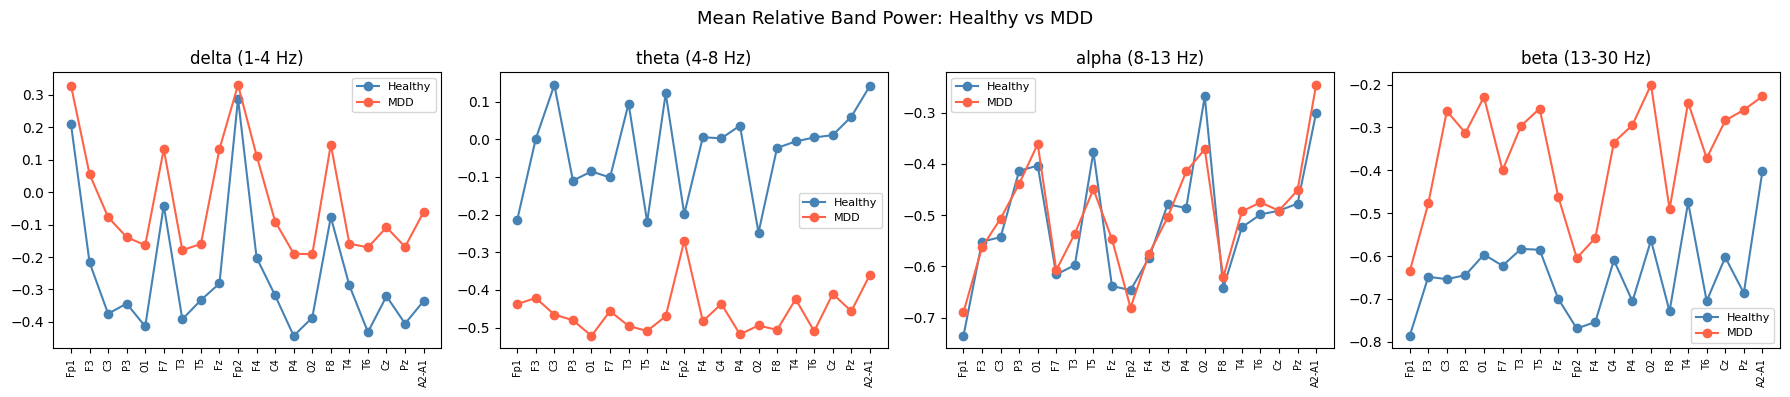

In [5]:
# Split the scaled feature matrix by class label

X_healthy = X_scaled[y == 0]   # healthy controls
X_mdd     = X_scaled[y == 1]   # MDD patients

print(f"Healthy recordings : {len(X_healthy)}  (label = 0)")
print(f"MDD recordings     : {len(X_mdd)}  (label = 1)")
print(f"Feature vector size: {X_scaled.shape[1]}")

# Visualise the mean band-power profile for each class across all 20 channels
band_names    = ['delta', 'theta', 'alpha', 'beta']
channel_names = [
    'Fp1','F3','C3','P3','O1','F7','T3','T5','Fz',
    'Fp2','F4','C4','P4','O2','F8','T4','T6','Cz','Pz','A2-A1'
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Mean Relative Band Power: Healthy vs MDD", fontsize=13)

for b, (ax, band) in enumerate(zip(axes, band_names)):
    # features for this band = every 4th value starting at offset b
    healthy_band = X_healthy[:, b::4].mean(axis=0)
    mdd_band     = X_mdd[:, b::4].mean(axis=0)

    x = range(len(channel_names))
    ax.plot(x, healthy_band, marker='o', label='Healthy', color='steelblue')
    ax.plot(x, mdd_band,     marker='o', label='MDD',     color='tomato')
    ax.set_title(f"{band} ({['1-4','4-8','8-13','13-30'][b]} Hz)")
    ax.set_xticks(list(x))
    ax.set_xticklabels(channel_names, rotation=90, fontsize=7)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()